# DEA WIT Change Detection Module <img align="right" src="dea_logo.jpg"/>

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with both the `NCI` and `DEA Sandbox` environments
* **Products used:** 
[ga_s2am_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2am_ard_3), 
[ga_s2bm_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2bm_ard_3),
[ga_s2cm_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2cm_ard_3),
[ga_ls5t_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls5t_ard_3),
[ga_ls7e_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls7e_ard_3),
[ga_ls8c_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls8c_ard_3)
* **Special requirements:** An _optional_ description of any special requirements, e.g. If running on the [NCI](https://nci.org.au/), ensure that `module load otps` is run prior to launching this notebook
* **Prerequisites:** An _optional_ list of any notebooks that should be run or content that should be understood prior to launching this notebook

## Background

(copied from WIT tool) Wetlands provide a wide range of ecosystem services including improving water quality, carbon sequestration, as well as providing habitat for fish, amphibians, reptiles and birds.  Managing wetlands in Australia is challenging due to competing pressures for water availability and highly variable climatic settings.  

The DEA WIT Change Detection tool is a module for the Wetland Insight Tool (WIT), which assists in the detection and analysis of changes in wetlands and water bodies across Australia. This tool suppports the National Wetland Inventory Project, which is a collaborative effort between Geoscience Australia and the Department of Climate Change, Energy, Environment and Water (DCCEEW). By contributing to the National Wetlands Inventory, this work helps build a vital reporting tool for monitoring the health and condition of Australia’s wetlands, supporting managers and authorities at local, state, and federal levels.

## Description
This notebook is a module for the WIT tool. It enables users to input spatial and temporal parameters, facilitating the detection of changes in wetlands and water bodies over time. The tool also validates change points by pulling satellite imagery before and after the change occurred.

1. Load and Prepare WIT data

#Table of contents?




## Workflow Implemented

![workflow](workflowCD_draft.png)


## Related Products

* [DEA Wetlands Insight Tool (Ramsar Wetlands)](https://knowledge.dea.ga.gov.au/data/product/dea-wetlands-insight-tool-ramsar-wetlands/)
* [DEA Fractional Cover](https://knowledge.dea.ga.gov.au/data/product/dea-fractional-cover-landsat/)
* [DEA Tasseled Cap Indices Percentiles Calendar Year (Landsat)](https://knowledge.dea.ga.gov.au/data/product/dea-tasseled-cap-percentiles-landsat/)
* [DEA Water Observations (Landsat)](https://knowledge.dea.ga.gov.au/data/product/dea-water-observations-landsat/)

***

# Getting Started

### Install Software

In [1]:
!pip install pymannkendall
!pip install matplotlib-scalebar

### Load Packages
Import Python packages that are used for the analysis.


In [54]:
import datacube
import sys
import dea_tools
sys.path.insert(1, '../Tools/')
from dea_tools.plotting import display_map, rgb
#from dea_tools.wetlands import WIT_drill, spatial_wit
import os
import re
import itertools
import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import datetime
import glob
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
import matplotlib.patches as mpatches
from statsmodels.tsa.seasonal import seasonal_decompose
from datacube.utils.geometry import Geometry, CRS
from matplotlib.colors import Normalize
from matplotlib_scalebar.scalebar import ScaleBar
from datacube import Datacube
import datacube
import dea_tools.datahandling
import dea_tools.bandindices
from pymannkendall.pymannkendall import (
    __preprocessing,
    __missing_values_analysis,
    __mk_score,
    __variance_s,
    __z_score,
    __p_value,
    sens_slope,
)
import importlib.util

# Add Tools directory to path first
tools_path = os.path.abspath('../Tools/')
if tools_path not in sys.path:
    sys.path.insert(0, tools_path)

# Load the local wetlands module
wetlands_file = os.path.join(tools_path, 'dea_tools', 'wetlands.py')

if os.path.exists(wetlands_file):
    print("Found local wetlands.py")
    try:
        # Load the module
        spec = importlib.util.spec_from_file_location("dea_tools.wetlands", wetlands_file)
        if spec is None:
            print("❌ Could not create spec from file")
        else:
            wetlands_local = importlib.util.module_from_spec(spec)
            
            # Try to execute the module
            try:
                spec.loader.exec_module(wetlands_local)
                print("✅ Module loaded successfully")
                
                # Check for WIT_drill
                if hasattr(wetlands_local, 'WIT_drill'):
                    WIT_drill = wetlands_local.WIT_drill
                    print("✅ Successfully imported WIT_drill")
                else:
                    print("❌ WIT_drill not found after loading")
                    print(f"Available attributes: {[x for x in dir(wetlands_local) if not x.startswith('_')][:20]}")
            except Exception as load_error:
                print(f"❌ Error executing module: {load_error}")
                import traceback
                traceback.print_exc()
                
    except Exception as e:
        print(f"❌ Error loading module: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"❌ Local wetlands.py not found at: {wetlands_file}")
    print(f"Current directory: {os.getcwd()}")
    print(f"Tools path: {tools_path}")

if os.path.exists(wetlands_file):
    print("Found local wetlands.py")
    try:
        # Load the module
        spec = importlib.util.spec_from_file_location("dea_tools.wetlands", wetlands_file)
        if spec is None:
            print("❌ Could not create spec from file")
        else:
            wetlands_local = importlib.util.module_from_spec(spec)
            
            # Try to execute the module
            try:
                spec.loader.exec_module(wetlands_local)
                print("✅ Module loaded successfully")
                
                # Check for spatial_wit
                if hasattr(wetlands_local, 'spatial_wit'):
                    spatial_wit = wetlands_local.spatial_wit
                    print("✅ Successfully imported spatial_wit")
                else:
                    print("❌ spatial_wit not found after loading")
                    print(f"Available attributes: {[x for x in dir(wetlands_local) if not x.startswith('_')][:20]}")
            except Exception as load_error:
                print(f"❌ Error executing module: {load_error}")
                import traceback
                traceback.print_exc()
                
    except Exception as e:
        print(f"❌ Error loading module: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"❌ Local wetlands.py not found at: {wetlands_file}")
    print(f"Current directory: {os.getcwd()}")
    print(f"Tools path: {tools_path}")

Found local wetlands.py


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/38411/status,
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/38411/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44153,Workers: 1
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/38411/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:39959,Total threads: 2
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/45641/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:33379,


✅ Module loaded successfully
✅ Successfully imported WIT_drill
Found local wetlands.py


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/39585/status,
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/39585/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36823,Workers: 1
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/39585/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:42651,Total threads: 2
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/40631/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:46393,


✅ Module loaded successfully
✅ Successfully imported spatial_wit


2025-11-13 06:13:11,681 - distributed.scheduler - WARNING - Detected different `run_spec` for key 'dataset-b6a03bb420034ea7916c9a58903370ff' between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x7f41ec9023b0>, (Dataset <id=b6a03bb4-2003-4ea7-916c-9a58903370ff product=ga_ls5t_ard_3 location=s3://dea-public-data/baseline/ga_ls5t_ard_3/090/085/2009/03/06/ga_ls5t_ard_3-0-0_090085_2009-03-06_final.stac-item.json>,), {})
new run_spec: (<function execute_task at 0x7f41ec9023b0>, (Dataset <id=b6a03bb4-2003-4ea7-916c-9a58903370ff product=ga_ls5t_ard_3 location=s3://dea-public-data/baseline/ga_ls5t_ard_3/090/08

# Parameters to Change
This code chunk lists the parameters that will be used as the input for this tool. the `csv_path` is the output from the Wetland Index Tool and the `component` represents the class to investigate the change detection for. The `polygon_path` variable should be the same spatial input that was put into the WIT tool for use in validating the change point imagery for that area. 

(time_windows_days i want to remove.)

In [25]:
csv_path = "178.csv"              # ACTION: Add CSV output from WIT tool (This is from DEA Maps)
component = "WET"                   # CHANGE THIS to the component you want to analyze (e.g. "PV", "GV", "NPV", "WET", "WATER")
polygon_path = "ginini_flats.shp"  # ACTION: change this if your polygon file has another name
time_window_days = 15              # how many days before/after to search for imagery

# Create output folder for validation images
out_folder = "validation_images"
os.makedirs(out_folder, exist_ok=True)

### Connect to the Datacube
Connect to the datacube so we can access DEA data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [26]:
dc = Datacube(app="change_detection_validation")
df = pd.read_csv(csv_path)
df["TIME"] = pd.to_datetime(df["TIME"])
df = df.sort_values("TIME").reset_index(drop=True)

## Prepare Data 

This code chunk edits out low quality data and smooths it to improve readability and reduce noise.   

In [27]:
def generate_low_quality_data_periods(df):
    """
    Mark periods with low-quality data:
    - Landsat 5-8 SLC-off gap (Nov 2011 - Apr 2013)
    - Low observation density (less than 4 observations in 365 days)
    """
    df = df.copy()
    df["off_value"] = 0
    
    # Landsat 5-8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100
    
    # Low observation density (less than 4 in 365 days)
    # Sort by time to ensure proper sequential checking
    df_sorted = df.sort_values('TIME').reset_index(drop=True)
    for i in range(len(df_sorted) - 3):
        if (df_sorted.loc[i + 3, "TIME"] - df_sorted.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df_sorted.loc[i, "TIME"])
                & (df["TIME"] <= df_sorted.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100
    return df

df = generate_low_quality_data_periods(df)

if component not in df.columns:
    raise ValueError(f"Component '{component}' not found in CSV columns: {list(df.columns)}")

# Create low quality ranges - groups low quality consecutive periods and records the start and end dates

low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

# Smooth data

pv = df.set_index("TIME")[component].astype(float)
pv = pv.resample('MS').mean().interpolate(method='cubic')  # Smooth monthly data using MS and interpolate the missing months with cubic interpolation

# Time Series Decomposition and Change Detection
This code removes large temporal gaps larger than 60 days (~2 months) and decomposes the time series into trend, seasonal and residual data using an additive model over a 12 month period. It also detects abrupt changes when statistics beyond the below number of standard deviations is flagged as an abrupt change.

In [28]:
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

if len(pv_filtered) < 24:
    print(f"Not enough data for {component}, skipping.")
else:
    result = seasonal_decompose(pv_filtered, model="additive", period=12)
    trend = result.trend
    seasonal = result.seasonal
    resid = result.resid

threshold = 2 * resid.std()                                  #ACTION: Adjust threshold for more sensitive change detection (2 is the default as it follows the 2-sigma rule)
change_points = resid[abs(resid) > threshold].index
change_points_sorted = sorted(change_points)

 # PLOT: Time Series Decomposition

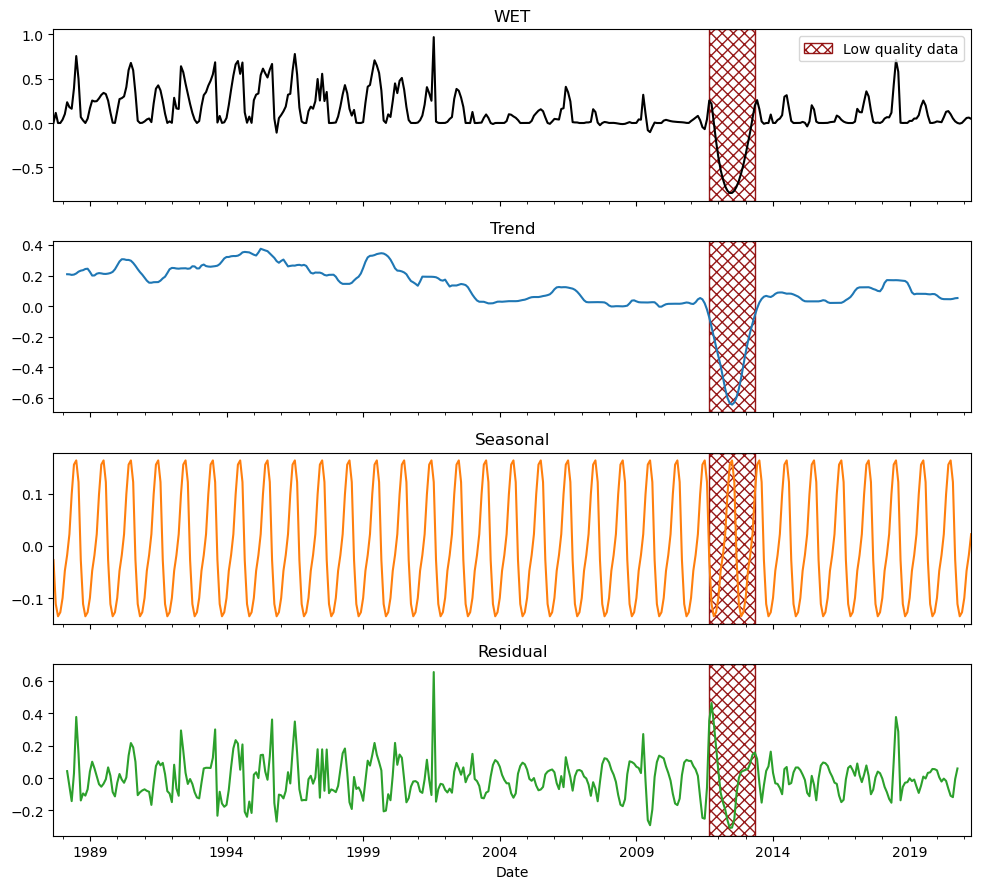

In [29]:
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

pv.plot(ax=axes[0], title=f"{component}", color="black")
trend.plot(ax=axes[1], title="Trend", color="tab:blue")
seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
resid.plot(ax=axes[3], title="Residual", color="tab:green")

    # Shade low-quality data
for ax in axes:
    for start, end in low_quality_ranges:
        ax.axvspan(start, end, facecolor="none", edgecolor="darkred", 
                    hatch="xxx", alpha=0.9)

# Add legend for low-quality data 
low_quality_patch = mpatches.Patch(
    facecolor="none", edgecolor="darkred", hatch="xxx", label="Low quality data", alpha=0.9
)

# Add the legend to just the top plot (or whichever you want)
axes[0].legend(handles=[low_quality_patch], loc="upper right", frameon=True)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# Gradual Change
Gradual change is calculated for robust trends using Theil-Sen regression with Mann-Kendall significance. The slope and p-value are calculated to determine if the component is undergoing a positive or negative trend as well as the significance of this trend. For gradual changes, code needs to be at least 4 years/ 50 observations so there are no false positives. 

WET is decreasing at 0.0043 per year on average (p-value: 0.0000)


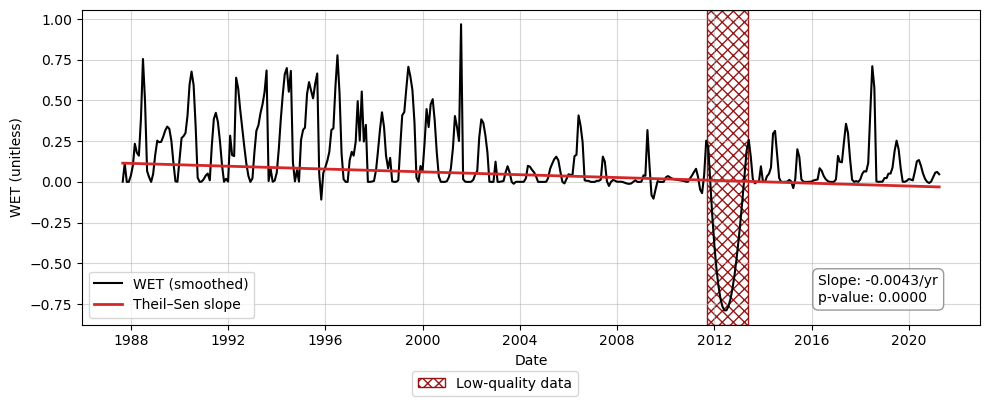

In [30]:
def mk_with_slopes(y, alpha=0.05):
    """
    Mann-Kendall test (Mann 1945, Kendall 1975, Gilbert 1987)
    Returns p-value, slope, and intercept.
    """
    res = namedtuple('Mann_Kendall_Test', ['p', 'slope', 'intercept'])

    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method='skip')
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    slope, intercept = sens_slope(y)

    return res(p, slope, intercept)

# Smooth component after analysis (cubic monthly interpolation)

df["TIME"] = pd.to_datetime(df["TIME"])
df = df.sort_values("TIME").reset_index(drop=True)

#Smooth component time series for plotting

smoothed = df.set_index("TIME")[component].resample("MS").mean().interpolate(method="cubic")

# Run Mann–Kendall and Theil–Sen slope
mk_result = mk_with_slopes(smoothed)
p = mk_result.p
slope = mk_result.slope
intercept = mk_result.intercept

# Calculate per-year slope (slope is per month, so multiply by 12)
slope_per_year = slope * 12

# Print trend comment before plotting
if slope > 0:
    print(f"{component} is increasing at {slope_per_year:.4f} per year on average (p-value: {p:.4f})")
elif slope < 0:
    print(f"{component} is decreasing at {abs(slope_per_year):.4f} per year on average (p-value: {p:.4f})")
else:
    print(f"{component} shows no trend (slope: {slope_per_year:.4f} per year, p-value: {p:.4f})")

# Prepare Theil–Sen regression line
x_num = date2num(smoothed.index)
y_line = np.arange(len(smoothed)) * slope + intercept

# Plot smoothed data + Theil–Sen line + low-quality shading
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# Smoothed data
ax.plot(smoothed.index, smoothed, color="black", label=f"{component} (smoothed)")

# Theil–Sen slope line
ax.plot(smoothed.index, y_line, color="tab:red", linewidth=2, label="Theil–Sen slope")

# Shade low-quality data
low_quality_patch = mpatches.Patch(facecolor="none", edgecolor="darkred", 
                                   hatch="xxx", label="Low-quality data", alpha=0.9)

for start, end in low_quality_ranges:
    ax.axvspan(start, end, facecolor="none", edgecolor="darkred", hatch="xxx", alpha=0.9)

# Annotate slope and p-value
textstr = f"Slope: {slope*12:.4f}/yr\np-value: {p:.4f}"
ax.text(
    0.82, 0.16, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

# Final layout and styling
ax.set_ylabel(f"{component} (unitless)")
ax.set_xlabel("Date")
ax.grid(alpha=0.5)

# Legend below plot
fig.legend(
    handles=[low_quality_patch],
    loc="lower center",
    ncol=1,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

ax.legend(loc='lower left', frameon=True)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

# Abrupt Change
This code utilises the decomposition plot and flags the change detection based on entries over the 2 x standard deviation threshold (2-sigma).

Low-quality range: 2011-09-11 to 2013-05-20

Before low-quality filtering: 14 change points
  - 1988-07-01
  - 1992-05-01
  - 1993-08-01
  - 1995-09-01
  - 1995-11-01
  - 1996-07-01
  - 2001-08-01
  - 2009-04-01
  - 2009-07-01
  - 2011-06-01
  - 2011-11-01
  - 2012-05-01
  - 2012-08-01
  - 2018-07-01
  REMOVED (low-quality): 2011-11-01
  REMOVED (low-quality): 2012-05-01
  REMOVED (low-quality): 2012-08-01

Final change points: 11
  1. 1988-07-01
  2. 1992-05-01
  3. 1993-08-01
  4. 1995-09-01
  5. 1995-11-01
  6. 1996-07-01
  7. 2001-08-01
  8. 2009-04-01
  9. 2009-07-01
  10. 2011-06-01
  11. 2018-07-01

Threshold: 0.2410 (2 × std = 0.1205)


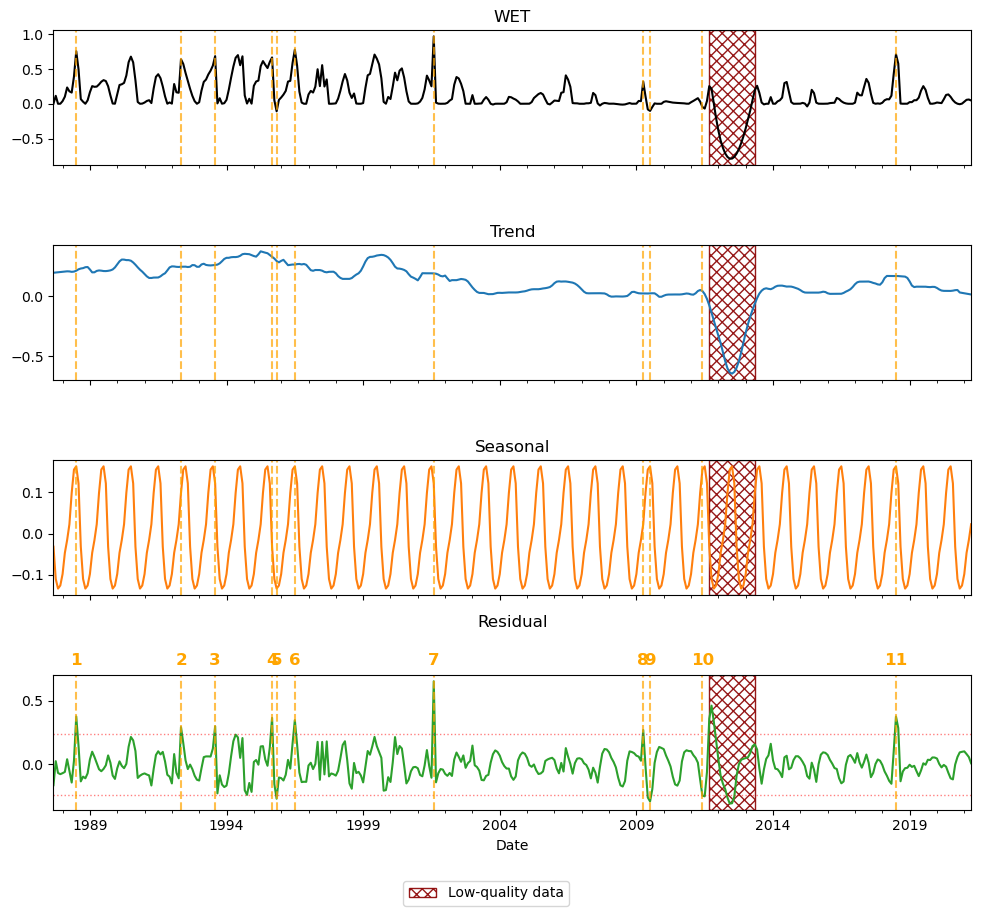

In [42]:
def generate_low_quality_data_periods(df):
  
    df = df.copy()
    df["off_value"] = 0
    
    # Landsat 5-8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100
    
    # Low observation density (less than 4 in 365 days)
    df_sorted = df.sort_values('TIME').reset_index(drop=True)
    for i in range(len(df_sorted) - 3):
        if (df_sorted.loc[i + 3, "TIME"] - df_sorted.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df_sorted.loc[i, "TIME"])
                & (df["TIME"] <= df_sorted.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100
    return df

def is_in_low_quality_range_strict(date, low_quality_ranges):
    """
    Strictly check if a date falls within low-quality range, including boundaries.
    """
    for start, end in low_quality_ranges:
        # Check if date is within or very close to the range (within 1 month)
        buffer = pd.Timedelta(days=31)
        if (start - buffer) <= date <= (end + buffer):
            return True
    return False

def identify_steep_slope_regions(resid, threshold_multiplier=2.0, slope_window_months=3):

    resid_clean = resid.dropna()
    if len(resid_clean) < 12:
        return []
    
    threshold = threshold_multiplier * resid_clean.std()
    
    # Find all points exceeding threshold
    exceeds_threshold = abs(resid_clean) > threshold
    candidate_dates = resid_clean.index[exceeds_threshold].tolist()
    
    if len(candidate_dates) < 2:
        return candidate_dates
    
    # Group consecutive points that are close together (within slope_window_months)
    slope_regions = []
    current_region = [candidate_dates[0]]
    
    for i in range(1, len(candidate_dates)):
        days_diff = (candidate_dates[i] - candidate_dates[i-1]).days
        if days_diff < slope_window_months * 30:  # Within the window
            current_region.append(candidate_dates[i])
        else:
            # End of current region
            if len(current_region) >= 2:
                # This is a steep slope region - keep only start and end
                slope_regions.append((current_region[0], current_region[-1]))
            else:
                # Single point, not a slope - keep it as is
                slope_regions.append((current_region[0], current_region[0]))
            current_region = [candidate_dates[i]]
    
    # Handle last region
    if len(current_region) >= 2:
        slope_regions.append((current_region[0], current_region[-1]))
    else:
        slope_regions.append((current_region[0], current_region[0]))
    
    # Extract change points: start and end of each region, or single points
    change_points = []
    for start, end in slope_regions:
        if start == end:
            # Single point
            change_points.append(start)
        else:
            # Steep slope region - keep only start and end
            change_points.append(start)
            # Only add end if it's significantly separated from start (at least 2 months)
            if (end - start).days >= 60:
                change_points.append(end)
            # Otherwise just keep the start
    return sorted(set(change_points))

# Validate component exists
if component not in df.columns:
    raise ValueError(f"Component '{component}' not found in CSV columns: {list(df.columns)}")

# Ensure TIME is datetime type
if not pd.api.types.is_datetime64_any_dtype(df['TIME']):
    df['TIME'] = pd.to_datetime(df['TIME'])

# Mark low-quality data periods
df = generate_low_quality_data_periods(df)

# Create low quality ranges
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))
        print(f"Low-quality range: {start.date()} to {end.date()}")

# Prepare data
pv = df.set_index("TIME")[component].astype(float)

# Smooth data BEFORE decomposition
pv_smooth = pv.resample('MS').mean().interpolate(method='cubic')

# Filter large gaps (>60 days)
gaps = pv_smooth.index.to_series().diff().dt.days
pv_filtered = pv_smooth.loc[gaps.fillna(1) < 60]

# Check if we have enough data
if len(pv_filtered) < 24:
    print(f"Not enough data for {component}, skipping.")
else:
    # Decompose time series using smoothed, filtered data
    result = seasonal_decompose(
        pv_filtered, 
        model="additive", 
        period=12,
        extrapolate_trend='freq'
    )
    
    trend = result.trend
    seasonal = result.seasonal
    resid = result.resid.dropna()
    
    # Identify steep slope regions (this handles clustering automatically)
    change_points_detected = identify_steep_slope_regions(
        resid, 
        threshold_multiplier=2.0,
        slope_window_months=4  # Points within 4 months are considered part of same slope
    )
    
    print(f"\nBefore low-quality filtering: {len(change_points_detected)} change points")
    for cp in change_points_detected:
        print(f"  - {cp.date()}")
    
    # STRICTLY filter out change points in low-quality ranges
    change_points_filtered = []
    for cp in change_points_detected:
        if not is_in_low_quality_range_strict(cp, low_quality_ranges):
            change_points_filtered.append(cp)
        else:
            print(f"  REMOVED (low-quality): {cp.date()}")
    
    change_points_sorted = sorted(change_points_filtered)
    
    print(f"\nFinal change points: {len(change_points_sorted)}")
    for idx, cp in enumerate(change_points_sorted, start=1):
        print(f"  {idx}. {cp.date()}")
    print(f"\nThreshold: {2.0 * resid.std():.4f} (2 × std = {resid.std():.4f})")
    
    # Plot
    fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
    
    pv_filtered.plot(ax=axes[0], title=f"{component}", color="black")
    result.trend.plot(ax=axes[1], title="Trend", color="tab:blue")
    result.seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
    result.resid.plot(ax=axes[3], color="tab:green")
    axes[3].set_title("Residual", pad=35)
    
    # Show threshold lines
    threshold_val = 2.0 * resid.std()
    axes[3].axhline(y=threshold_val, color='r', linestyle=':', alpha=0.5, linewidth=1, label='±2σ threshold')
    axes[3].axhline(y=-threshold_val, color='r', linestyle=':', alpha=0.5, linewidth=1)
    
    # Label axes
    axes[-1].set_xlabel("Date")
    
    # Shade low-quality data
    low_quality_patch = mpatches.Patch(facecolor="none", edgecolor="darkred", 
                                       hatch="xxx", label="Low-quality data", alpha=0.9)
    
    for ax in axes:
        for start, end in low_quality_ranges:
            ax.axvspan(start, end, facecolor="none", edgecolor="darkred", 
                       hatch="xxx", alpha=0.9)
    
    # Mark and label change points
    for idx, cp in enumerate(change_points_sorted, start=1):
        for ax in axes:
            ax.axvline(cp, color="orange", linestyle="--", alpha=0.7, linewidth=1.5)
        axes[3].text(
            cp,
            y_pos,
            str(idx),
            color="orange",
            fontsize=12,
            fontweight="bold",
            ha="center",
            rotation=0,
            clip_on=False,
        )
    
    # Legend
    fig.legend(
        handles=[low_quality_patch],
        loc="lower center",
        ncol=1,
        frameon=True,
        bbox_to_anchor=(0.5, -0.02)
    )
    
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()
    

## Create dataframe with change ID and date

In [32]:
change_data = pd.DataFrame({
    "Change_ID": range(1, len(change_points_sorted) + 1),
    "Timestamp": change_points_sorted
})
change_data

,Change_ID,Timestamp
0,1,1988-07-01
1,2,1992-05-01
2,3,1993-08-01
3,4,1995-09-01
4,5,1995-11-01
5,6,1996-07-01
6,7,2001-08-01
7,8,2009-04-01
8,9,2009-07-01
9,10,2011-06-01


# Validation imagery
Find imagery for change points

In [35]:
#take change points to plot where cp> Y+2std

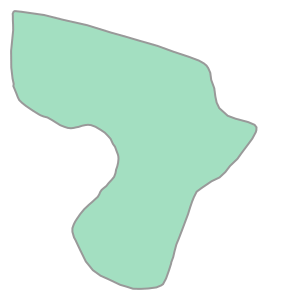

In [36]:
ginini = gpd.read_file(polygon_path)
ginini = Geometry(ginini.geometry[0], CRS(str(ginini.crs)))
ginini

In [37]:
ds_wit, polygon_base_df = WIT_drill(ginini, ("2009-03", "2009-05"))

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3 (ignoring SLC-off observations)
    ga_ls5t_ard_3
Applying fmask pixel quality/cloud mask
Returning 9 time steps as a dask array
Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2']


'Ginini_Flats_animation.gif'

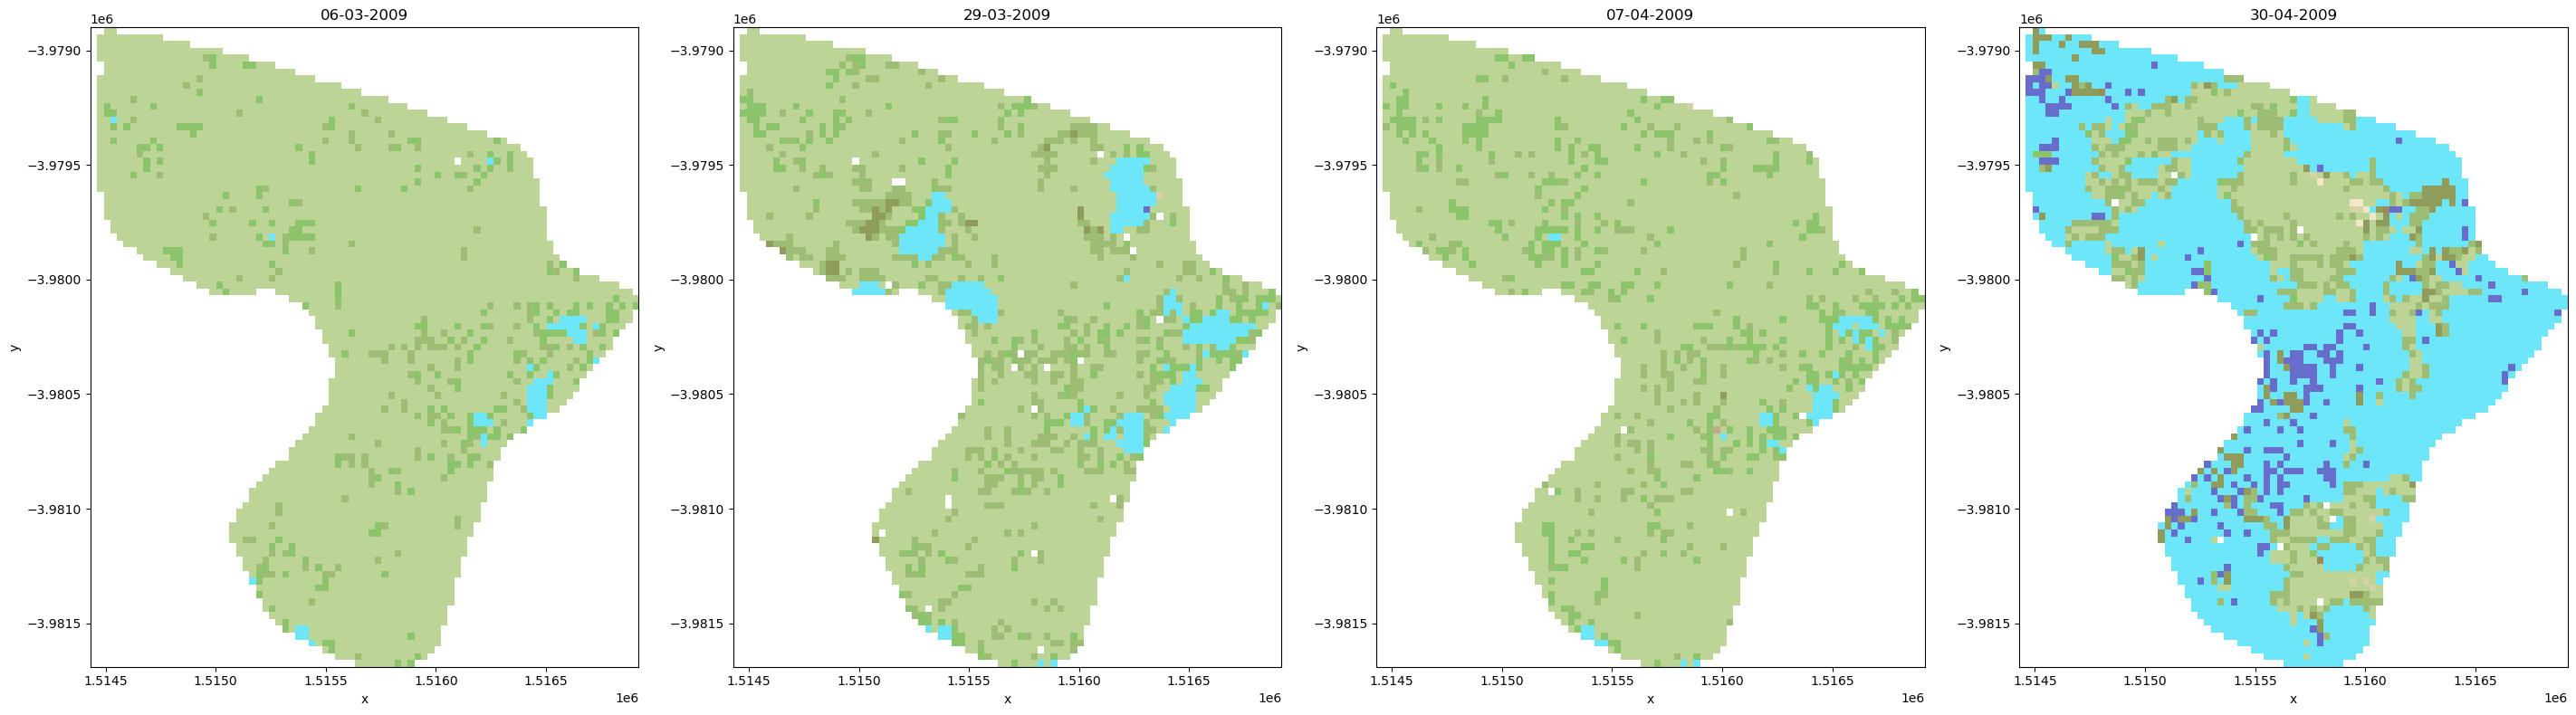

In [43]:
spatial_wit(ds_wit, "Ginini Flats")

In [55]:
# Define which spectral bands are being used in the analysis
bands = [
    f"nbart_{band}" for band in ("blue", "green", "red", "nir", "swir_1", "swir_2")
]

# Load Landsat 5, 7 and 8 data. Not including Landsat 7 SLC off period (31-05-2003 to 06-04-2022).
ds = dea_tools.datahandling.load_ard(
    dc,
    products=["ga_ls8c_ard_3", "ga_ls7e_ard_3", "ga_ls5t_ard_3"],
    measurements=bands,
    geopolygon=ginini,
    output_crs="EPSG:3577",
    resolution=(-30, 30),
    time=("2009-03", "2009-05"),                                           #ACTION: choose before and after month of change ID
    min_gooddata = 0.8,
    dask_chunks={"time": 1, "x": 2048, "y": 2048},
)

# Load into memory using Dask
ds.load()

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3
    ga_ls5t_ard_3
Counting good quality pixels for each time step using fmask
Filtering to 6 out of 24 time steps with at least 80.0% good quality pixels
Applying fmask pixel quality/cloud mask
Returning 6 time steps as a dask array


<xarray.Dataset> Size: 1MB
Dimensions:       (time: 6, y: 93, x: 83)
Coordinates:
  * time          (time) datetime64[ns] 48B 2009-03-06T23:37:02.938336 ... 20...
  * y             (y) float64 744B -3.979e+06 -3.979e+06 ... -3.982e+06
  * x             (x) float64 664B 1.514e+06 1.514e+06 ... 1.517e+06 1.517e+06
    spatial_ref   int32 4B 3577
Data variables:
    nbart_blue    (time, y, x) float32 185kB 242.0 248.0 257.0 ... 2.0 2.0 2.0
    nbart_green   (time, y, x) float32 185kB 512.0 523.0 498.0 ... 103.0 112.0
    nbart_red     (time, y, x) float32 185kB 544.0 542.0 585.0 ... 312.0 336.0
    nbart_nir     (time, y, x) float32 185kB 1.933e+03 1.954e+03 ... 2.609e+03
    nbart_swir_1  (time, y, x) float32 185kB 1.909e+03 1.889e+03 ... 728.0 963.0
    nbart_swir_2  (time, y, x) float32 185kB 1.159e+03 1.156e+03 ... 479.0 230.0
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

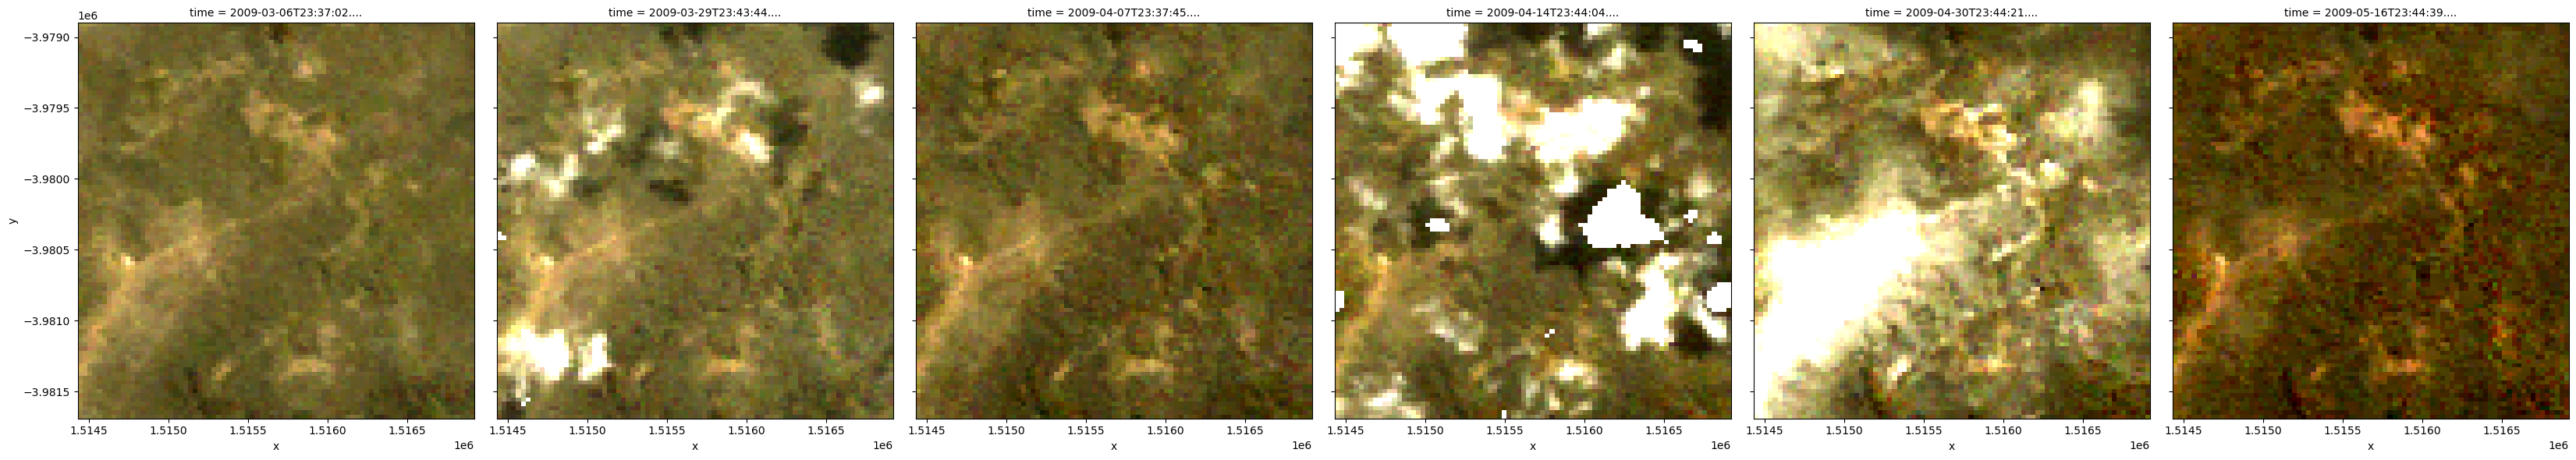

In [48]:
rgb(ds, bands=['nbart_red', 'nbart_green', 'nbart_blue'], col="time", col_wrap=6)

Error plotting polygon: 'str' object has no attribute 'crs'
Error plotting polygon: 'str' object has no attribute 'crs'
Error plotting polygon: 'str' object has no attribute 'crs'
Error plotting polygon: 'str' object has no attribute 'crs'
Error plotting polygon: 'str' object has no attribute 'crs'
Error plotting polygon: 'str' object has no attribute 'crs'


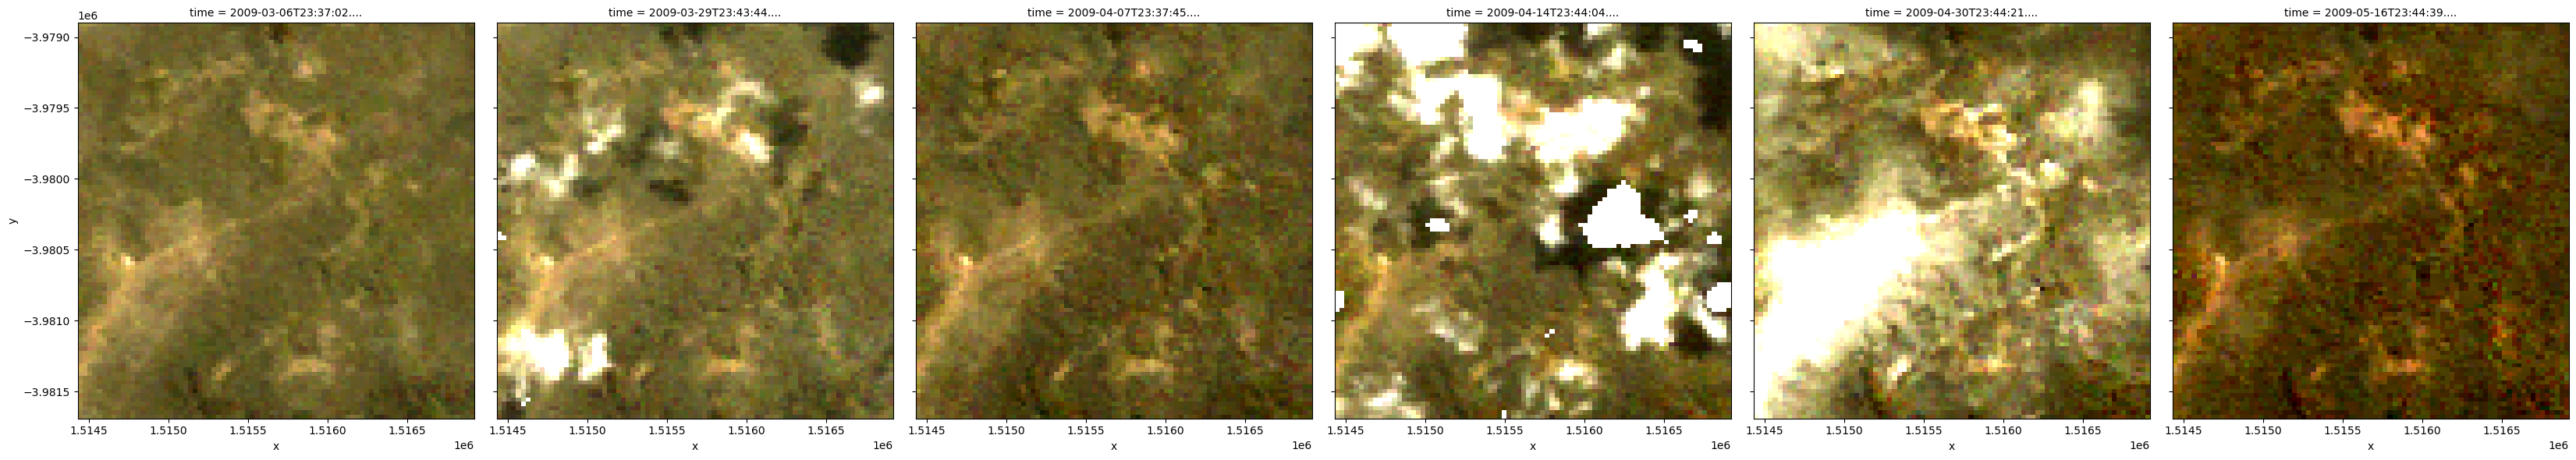

In [56]:
# Create RGB plot
rgb_plot = rgb(ds, bands=['nbart_red', 'nbart_green', 'nbart_blue'], col="time", col_wrap=6)
poly = "ginini.shp"

# Function to plot polygon on axis
def plot_polygon_on_axis(ax, poly):
    """Overlay polygon outline on the axis."""
    try:
        # Ensure polygon is in the same CRS as the data
        if poly.crs != CRS("EPSG:3577"):
            poly = poly.to_crs("EPSG:3577")
        
        for geom in poly.geometry:
            if geom.geom_type == 'Polygon':
                x, y = geom.exterior.xy
                ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9, transform=ax.transData)
            elif geom.geom_type == 'MultiPolygon':
                for poly_part in geom:
                    x, y = poly_part.exterior.xy
                    ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9, transform=ax.transData)
    except Exception as e:
        print(f"Error plotting polygon: {e}")

# Get the current figure (created by rgb())
fig = plt.gcf()

# Plot polygon on all subplot axes
for ax in fig.axes:
    plot_polygon_on_axis(ax, poly)

# Refresh the display
plt.draw()
plt.show()

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Citations** &mdash; If you use the DEA Notebooks and Tools repository in your work, please reference
it with the following citation:

> Krause, C., Dunn, B., Bishop-Taylor, R., Adams, C., Burton, C., Alger,
> M., Chua, S., Phillips, C., Newey, V., Kouzoubov, K., Leith, A.,
> Ayers, D., Hicks, A., DEA Notebooks contributors 2021. Digital Earth
> Australia notebooks and tools repository. Geoscience Australia,
> Canberra. <https://doi.org/10.26186/145234>

To cite this notebooks' dataset and research papers in your work you can use the [Publications](#Publications) at the top of this notebook.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** February 2025

**Compatible datacube version:** 

In [34]:
print(datacube.__version__)

1.8.19


## Tags

In [ ]:
**Tags**: :index:`calculate_indices`, :index:`sandbox compatible`, :index:`landsat 5`, :index:`landsat 7`, :index:`landsat 8`, :index:`time series`, :index:`Wetlands_Insight_Tool_(WIT)`, :index:`water observations`, :index:`fractional cover`, :index:`tasseled cap`